In [1]:
from google.cloud import storage
import pandas as pd
import os

# Cấu hình
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "gcp-key.json"
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/merged_real_estate_macro.parquet"
local_path = "../data/merged_real_estate_macro.parquet"

# Tải từ GCS nếu chưa có
if not os.path.exists(local_path):
    os.makedirs("../data", exist_ok=True)
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)
    blob.download_to_filename(local_path)
    print(f"✅ Downloaded from GCS → {local_path}")


✅ Downloaded from GCS → ../data/merged_real_estate_macro.parquet


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


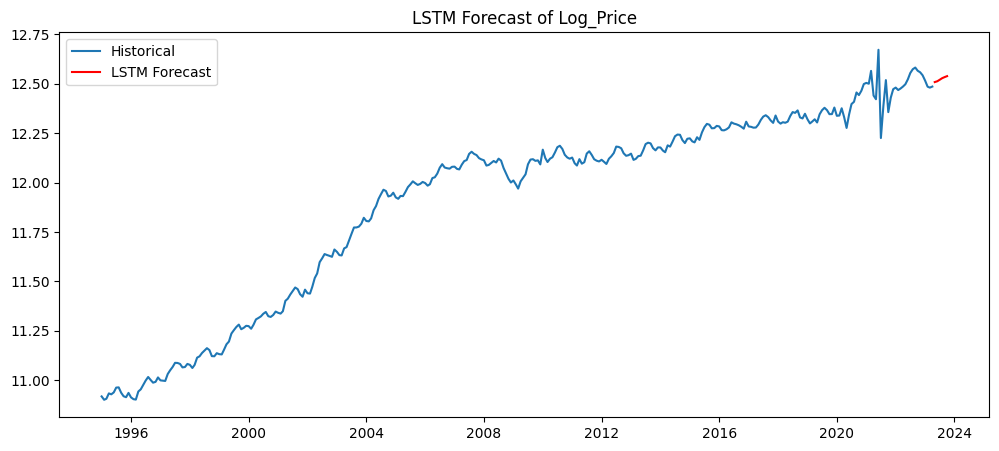

In [2]:
# 📚 LSTM Forecasting for UK Real Estate Prices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# 🧱 Load data
df = pd.read_parquet('../data/merged_real_estate_macro.parquet')
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df_monthly = df.groupby('Date')[['Log_Price']].mean().reset_index()

# 📏 Normalize Log_Price
scaler = MinMaxScaler()
df_monthly['Scaled_Price'] = scaler.fit_transform(df_monthly[['Log_Price']])

# 🔁 Create sequence data
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12  # use 12 months to predict next
X, y = create_sequences(df_monthly['Scaled_Price'].values, seq_length)

# 👷‍♂️ Reshape for LSTM input
X = X.reshape((X.shape[0], X.shape[1], 1))

# 🧠 Build LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, batch_size=8, verbose=0, callbacks=[EarlyStopping(patience=10)])

# 🔮 Forecast next 6 months
last_seq = df_monthly['Scaled_Price'].values[-seq_length:]
forecast_scaled = []
current_input = last_seq.copy()

for _ in range(6):
    pred = model.predict(current_input.reshape(1, seq_length, 1))[0][0]
    forecast_scaled.append(pred)
    current_input = np.append(current_input[1:], pred)

# 🔁 Inverse transform
forecast_actual = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1)).flatten()

# 📅 Prepare date range
last_date = df_monthly['Date'].iloc[-1]
forecast_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=6, freq='MS')

# 📈 Plot result
plt.figure(figsize=(12,5))
plt.plot(df_monthly['Date'], df_monthly['Log_Price'], label='Historical')
plt.plot(forecast_dates, forecast_actual, label='LSTM Forecast', color='red')
plt.title('LSTM Forecast of Log_Price')
plt.legend()
plt.show()
